In [1]:

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.measure import regionprops

from tqdm import tqdm
import joblib
from rembg import remove

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


c:\Users\tuf51\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

DATASET_PATH = "DATASET"
IMG_SIZE = (128,128)


In [3]:

def load_dataset(dataset_path):

    images = []
    labels = []

    for label in sorted(os.listdir(dataset_path)):

        folder = os.path.join(dataset_path,label)

        if not os.path.isdir(folder):
            continue

        for file in os.listdir(folder):

            if file.lower().endswith(('.jpg','.jpeg','.png')):

                path = os.path.join(folder,file)

                img = cv2.imread(path)

                if img is None:
                    continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, IMG_SIZE)

                images.append(img)
                labels.append(label)

    return np.array(images), np.array(labels)

In [4]:
X_raw, y = load_dataset(DATASET_PATH)
print("Total Data :", len(X_raw))
print("Jumlah Kelas :", len(np.unique(y)))

Total Data : 279
Jumlah Kelas : 5


In [5]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [6]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

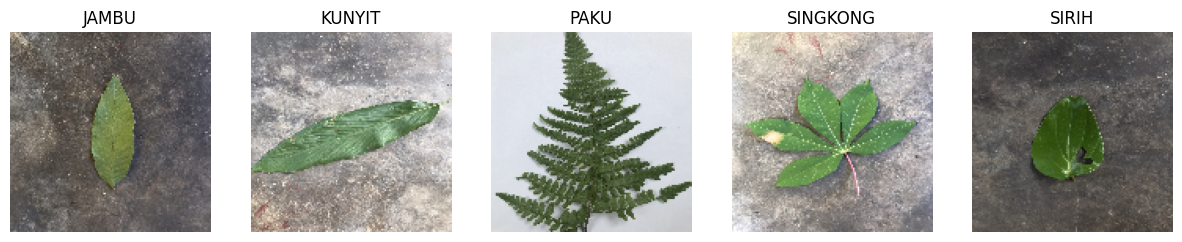

In [7]:
kelas_unik = sorted(np.unique(y))

fig, axes = plt.subplots(
    1,
    len(kelas_unik),
    figsize=(15,4)
)

for ax, label in zip(axes, kelas_unik):

    idx = np.where(y == label)[0][0]

    ax.imshow(X_raw[idx])
    ax.set_title(label)
    ax.axis("off")

plt.show()

In [8]:
def remove_bg(img):

    _, buffer = cv2.imencode('.png', cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    
    output_bytes = remove(buffer.tobytes())
    
    result = cv2.imdecode(np.frombuffer(output_bytes, np.uint8), cv2.IMREAD_UNCHANGED)
    
    if result.shape[2] == 4:
        alpha = result[:, :, 3]
        
        rgb = result[:, :, :3]
        
        rgb[alpha == 0] = [255, 255, 255]
        
        return cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
    
    return img

In [9]:
X_train_remove = []

for img_rgb in X_train_raw:

    img_no_bg = remove_bg(
        img_rgb
    )

    X_train_remove.append(
        img_no_bg
    )

In [10]:
X_test_remove = []

for img_rgb in X_test_raw:

    img_no_bg = remove_bg(
        img_rgb
    )

    X_test_remove.append(
        img_no_bg
    )

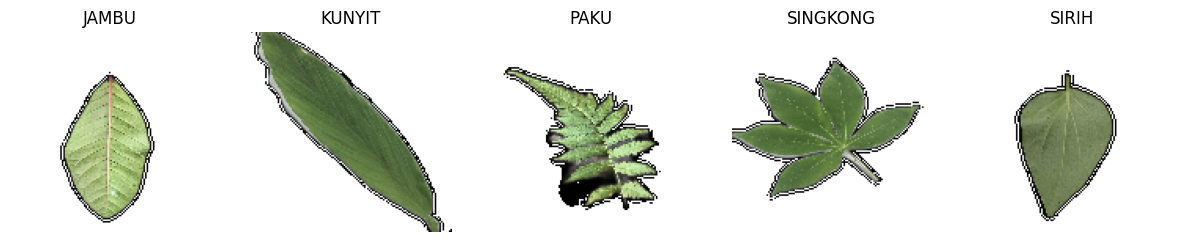

In [11]:
fig, axes = plt.subplots(
    1,
    len(kelas_unik),
    figsize=(15,4)
)

for ax, label in zip(axes, kelas_unik):

    idx = np.where(encoder.inverse_transform(y_train) == label)[0][0]

    ax.imshow(X_train_remove[idx])

    ax.set_title(label)

    ax.axis("off")

plt.show()

In [12]:
def augment_image(img):

    augmented = []

    augmented.append(img)

    # Flip horizontal
    augmented.append(
        cv2.flip(img,1)
    )

    # Rotasi +15
    M = cv2.getRotationMatrix2D(
        (IMG_SIZE[0]//2, IMG_SIZE[1]//2),
        15,
        1
    )

    augmented.append(
        cv2.warpAffine(
            img,
            M,
            IMG_SIZE,
            borderValue=(255,255,255)
        )
    )

    # Rotasi -15
    M = cv2.getRotationMatrix2D(
        (IMG_SIZE[0]//2, IMG_SIZE[1]//2),
        -15,
        1
    )

    augmented.append(
        cv2.warpAffine(
            img,
            M,
            IMG_SIZE,
            borderValue=(255,255,255)
        )
    )

    return augmented

In [13]:
X_train_aug = []
y_train_aug = []

for img, label in zip(X_train_remove, y_train):

    augmented = augment_image(img)

    for aug in augmented:

        X_train_aug.append(aug)
        y_train_aug.append(label)

X_train_aug = np.array(X_train_aug)
y_train_aug = np.array(y_train_aug)

In [14]:
def grayscale(img):

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2GRAY
    )

    return gray

In [15]:
gray_images = []

for img_bg in X_train_aug:

    gray = grayscale(
        img_bg
    )

    gray_images.append(
        gray
    )
gray_images = np.array(
    gray_images
)

In [16]:
gray_test = []

for img_bg in X_test_remove:

    gray = grayscale(
        img_bg
    )

    gray_test.append(
        gray
    )

gray_test = np.array(
    gray_test
)

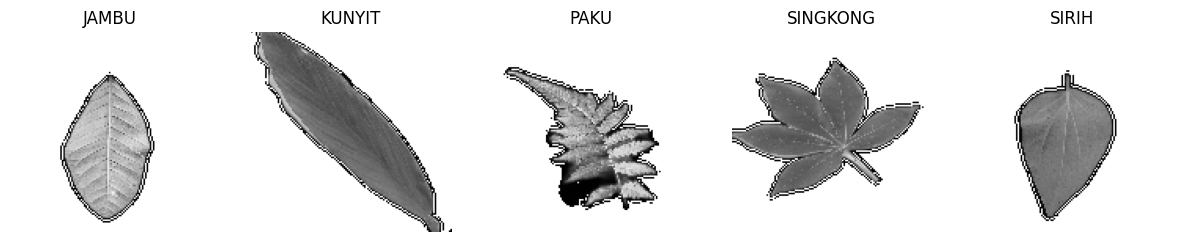

In [17]:
fig, axes = plt.subplots(
    1,
    len(kelas_unik),
    figsize=(15,4)
)

for ax, label in zip(axes, kelas_unik):

    idx = np.where(encoder.inverse_transform(y_train_aug) == label)[0][0]

    ax.imshow(
        gray_images[idx],
        cmap='gray'
    )

    ax.set_title(label)

    ax.axis("off")

plt.show()

In [18]:
def otsu_threshold(gray):
    _, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
    return thresh

In [19]:
thresh_images = []

for gray in gray_images:

    thresh = otsu_threshold(
        gray
    )

    thresh_images.append(
        thresh
    )
thresh_images = np.array(
    thresh_images
)

In [20]:
thresh_test = []

for gray in gray_test:

    thresh = otsu_threshold(
        gray
    )

    thresh_test.append(
        thresh
    )

thresh_test = np.array(
    thresh_test
)

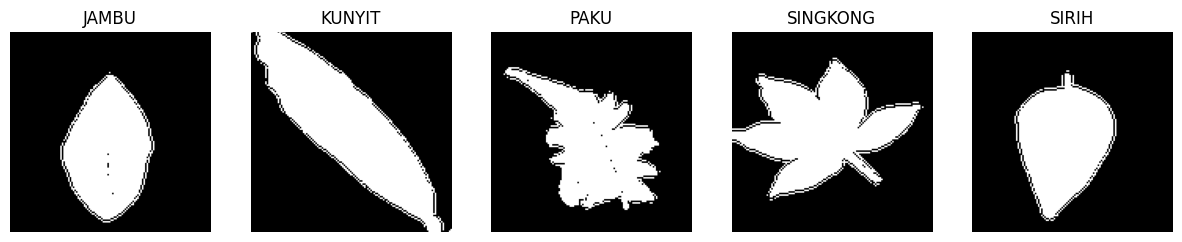

In [21]:
fig, axes = plt.subplots(
    1,
    len(kelas_unik),
    figsize=(15,4)
)

for ax, label in zip(axes, kelas_unik):

    idx = np.where(encoder.inverse_transform(y_train_aug) == label)[0][0]

    ax.imshow(
        thresh_images[idx],
        cmap='gray'
    )

    ax.set_title(label)

    ax.axis('off')

plt.show()

In [22]:
def contour_detection(thresh):

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:
        return None

    largest_contour = max(
        contours,
        key=cv2.contourArea
    )

    return largest_contour

In [23]:
contour_images = []

for thresh in thresh_images:

    contour = contour_detection(thresh)

    contour_images.append(
        contour
    )
contour_images = np.array(
    contour_images,
    dtype=object
)

In [24]:
contour_test = []

for thresh in thresh_test:

    contour = contour_detection(
        thresh
    )

    contour_test.append(
        contour
    )

contour_test = np.array(
    contour_test,
    dtype=object
)

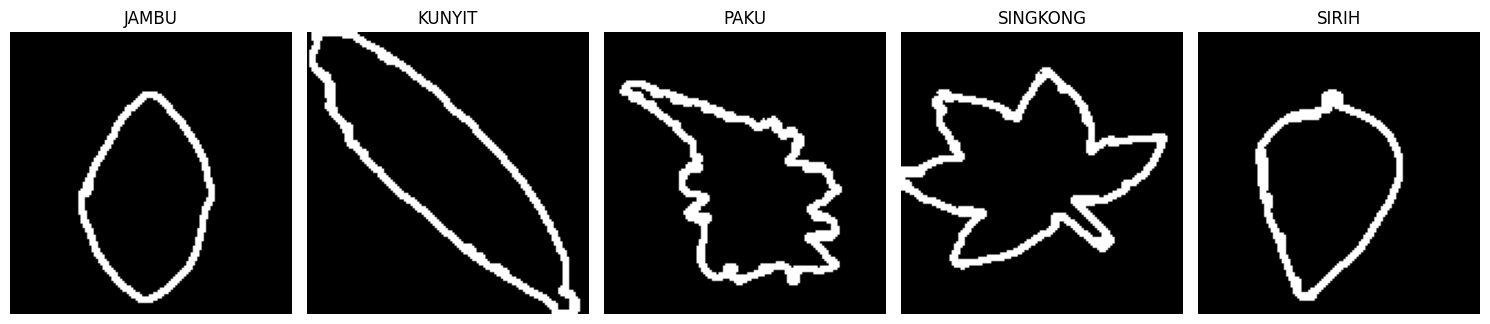

In [25]:
kelas_unik = encoder.classes_
labels = encoder.inverse_transform(y_train_aug)

fig, axes = plt.subplots(
    1,
    len(kelas_unik),
    figsize=(15,4)
)

for ax, label in zip(axes, kelas_unik):

    idx = np.where(labels == label)[0][0]

    # Canvas kosong
    contour_canvas = np.zeros(
        (IMG_SIZE[1], IMG_SIZE[0]),
        dtype=np.uint8
    )

    # Gambar contour jika ada
    if contour_images[idx] is not None:
        cv2.drawContours(
            contour_canvas,
            [contour_images[idx]],
            -1,
            255,
            2
        )

    ax.imshow(
        contour_canvas,
        cmap="gray"
    )

    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [26]:
def extract_glcm(gray):
    glcm = graycomatrix(gray, distances=[1, 3, 5], angles=[0, np.pi/2],
                        levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')
    correlation = graycoprops(glcm, 'correlation')
    features = list(contrast.flatten())
    features += list(correlation[:, 1])
    return np.array(features)

In [27]:
def extract_lbp(gray):
    selected = []
    lbp_r1 = local_binary_pattern(gray, 8, 1, method='uniform')
    hist_r1, _ = np.histogram(lbp_r1.ravel(), bins=np.arange(0, 11), range=(0, 10))
    hist_r1 = hist_r1.astype(float) / (hist_r1.sum() + 1e-7)
    selected.append(hist_r1[6])

    lbp_r2 = local_binary_pattern(gray, 16, 2, method='uniform')
    hist_r2, _ = np.histogram(lbp_r2.ravel(), bins=np.arange(0, 19), range=(0, 18))
    hist_r2 = hist_r2.astype(float) / (hist_r2.sum() + 1e-7)
    selected.extend([hist_r2[10], hist_r2[12], hist_r2[14]])
    return np.array(selected)

In [28]:
def extract_fd(contour, num_descriptors=40):
    if contour is None: return np.zeros(num_descriptors)
    contour = contour[:, 0, :]
    complex_contour = contour[:, 0] + 1j * contour[:, 1]
    fd = np.abs(np.fft.fft(complex_contour))
    fd = fd[1:(num_descriptors + 1)]
    if len(fd) > 0: fd = fd / (np.max(fd) + 1e-10)
    if len(fd) < num_descriptors: fd = np.pad(fd, (0, num_descriptors - len(fd)))
    return fd

In [29]:
def extract_shape(contour):

    if contour is None:
        return np.zeros(9)

    area = cv2.contourArea(contour)

    perimeter = cv2.arcLength(
        contour,
        True
    )

    x, y, w, h = cv2.boundingRect(contour)

    aspect_ratio = w / (h + 1e-10)

    rect_area = w * h

    extent = area / (rect_area + 1e-10)

    hull = cv2.convexHull(contour)

    hull_area = cv2.contourArea(hull)

    hull_perimeter = cv2.arcLength(
        hull,
        True
    )

    solidity = area / (hull_area + 1e-10)

    circularity = (
        4 * np.pi * area
    ) / ((perimeter ** 2) + 1e-10)

    convexity = hull_perimeter / (perimeter + 1e-10)

    mask = np.zeros(
        (IMG_SIZE[1], IMG_SIZE[0]),
        dtype=np.uint8
    )

    cv2.drawContours(
        mask,
        [contour],
        -1,
        255,
        -1
    )

    props = regionprops(mask)

    if len(props) > 0:

        eccentricity = props[0].eccentricity

    else:

        eccentricity = 0

    rectangularity = area / (rect_area + 1e-10)

    return np.array([

        area,
        perimeter,
        aspect_ratio,
        extent,
        solidity,
        circularity,
        convexity,
        eccentricity,
        rectangularity

    ])

In [30]:
def extract_features_scenario(gray, contour, scenario):

    glcm = extract_glcm(gray)
    lbp = extract_lbp(gray)
    fd = extract_fd(contour)
    shape = extract_shape(contour)

    if scenario == 1:
        return glcm

    elif scenario == 2:
        return lbp

    elif scenario == 3:
        return fd

    elif scenario == 4:
        return np.hstack([
            glcm,
            fd
        ])

    elif scenario == 5:
        return np.hstack([
            lbp,
            fd
        ])

    elif scenario == 6:
        return np.hstack([
            glcm,
            lbp,
            fd
        ])

    elif scenario == 7:
        return shape

    elif scenario == 8:
        return np.hstack([
            glcm,
            shape
        ])

    elif scenario == 9:
        return np.hstack([
            lbp,
            shape
        ])

    elif scenario == 10:
        return np.hstack([
            glcm,
            lbp,
            shape
        ])

In [31]:
SHORT_NAMES = {"SVM": "svm", "KNN": "knn", "Naive Bayes": "nb"}


def get_models():
    
    return {
        "SVM": SVC(kernel='linear', C=1, probability=True, random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Naive Bayes": GaussianNB()
    }

In [32]:
def train_scenario(X_train, y_train, X_test, y_test, scenario_num, encoder):
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = get_models()
    for model in models.values():
        model.fit(X_train_scaled, y_train)

    for name, model in models.items():
        joblib.dump(model, f"{SHORT_NAMES[name]}_s{scenario_num}.pkl")
    joblib.dump(scaler, f"scaler_s{scenario_num}.pkl")
    joblib.dump(encoder, "label_encoder.pkl")

    return models, scaler, X_train_scaled, X_test_scaled

In [33]:
def train_evaluate_save(X_train, y_train, X_test, y_test, scenario_num, encoder):
    
    print(f"\n{'#'*60}")
    print(f"SKENARIO {scenario_num} \u2014 shape fitur train: {X_train.shape}, test: {X_test.shape}")
    print(f"{'#'*60}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = get_models()
    results = {}

    for name, model in models.items():
        model.fit(X_train_scaled, y_train)

        train_acc = model.score(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        test_acc = accuracy_score(y_test, pred)

        print(f"\n{'='*50}")
        print(name)
        print(f"{'='*50}")
        print(f"Train Accuracy : {train_acc*100:.2f}%")
        print(f"Test Accuracy  : {test_acc*100:.2f}%")
        print(classification_report(y_test, pred, target_names=encoder.classes_))

        cm = confusion_matrix(y_test, pred)
        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=encoder.classes_, yticklabels=encoder.classes_)
        plt.title(f"Confusion Matrix {name} - Skenario {scenario_num}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

        joblib.dump(model, f"{SHORT_NAMES[name]}_s{scenario_num}.pkl")
        results[name] = {"train_acc": train_acc, "test_acc": test_acc}

    joblib.dump(scaler, f"scaler_s{scenario_num}.pkl")
    joblib.dump(encoder, "label_encoder.pkl")

    print(f"\nModel skenario {scenario_num} berhasil disimpan.")
    return results, scaler

In [34]:
SCENARIO_LABELS = {
    1: "1: GLCM",
    2: "2: LBP",
    3: "3: FD",
    4: "4: GLCM+FD",
    5: "5: LBP+FD",
    6: "6: GLCM+LBP+FD",
    7: "7: Shape",
    8: "8: GLCM+Shape",
    9: "9: LBP+Shape",
    10: "10: GLCM+LBP+Shape",
}

all_results = {}
all_scalers = {}


# SKENARIO 1

In [35]:
scenario = 1

X_train_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_images, contour_images)
])
X_test_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_test, contour_test)
])

models_s1, scaler_s1, Xtr_s1, Xte_s1 = train_scenario(
    X_train_feat, y_train_aug, X_test_feat, y_test, scenario, encoder
)
all_results[scenario] = {}
all_scalers[scenario] = scaler_s1

# SKENARIO 2


############################################################
SKENARIO 2 — shape fitur train: (892, 4), test: (56, 4)
############################################################

SVM
Train Accuracy : 61.77%
Test Accuracy  : 60.71%
              precision    recall  f1-score   support

       JAMBU       0.47      0.82      0.60        11
      KUNYIT       0.56      0.50      0.53        10
        PAKU       0.90      0.75      0.82        12
    SINGKONG       0.58      0.58      0.58        12
       SIRIH       0.67      0.36      0.47        11

    accuracy                           0.61        56
   macro avg       0.64      0.60      0.60        56
weighted avg       0.64      0.61      0.60        56



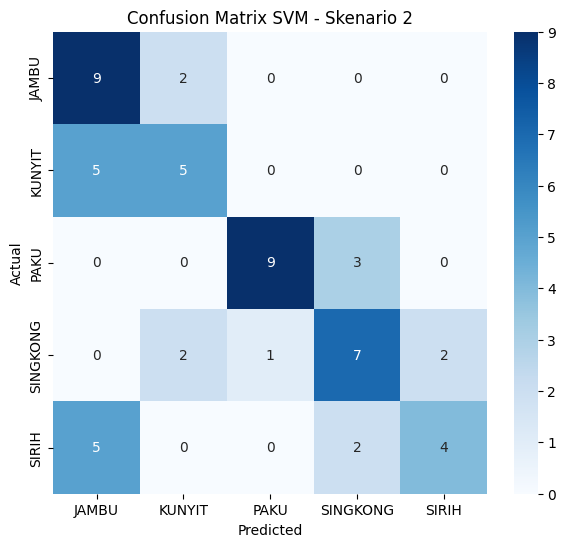


KNN
Train Accuracy : 84.08%
Test Accuracy  : 57.14%
              precision    recall  f1-score   support

       JAMBU       0.47      0.64      0.54        11
      KUNYIT       0.46      0.60      0.52        10
        PAKU       1.00      0.67      0.80        12
    SINGKONG       0.58      0.58      0.58        12
       SIRIH       0.50      0.36      0.42        11

    accuracy                           0.57        56
   macro avg       0.60      0.57      0.57        56
weighted avg       0.61      0.57      0.58        56



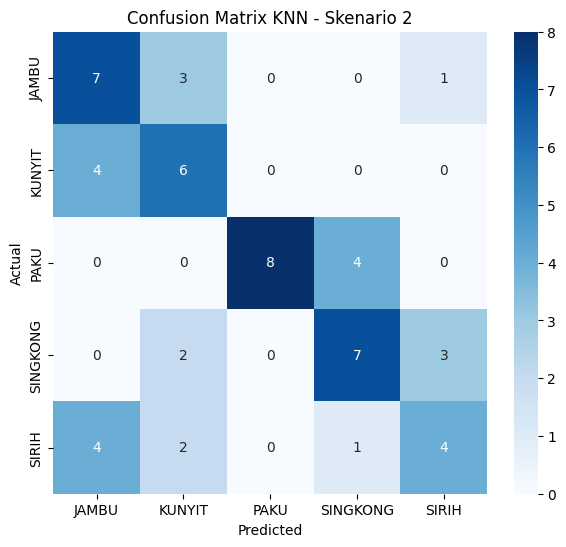


Naive Bayes
Train Accuracy : 45.85%
Test Accuracy  : 48.21%
              precision    recall  f1-score   support

       JAMBU       0.62      0.45      0.53        11
      KUNYIT       0.30      0.80      0.43        10
        PAKU       0.90      0.75      0.82        12
    SINGKONG       0.56      0.42      0.48        12
       SIRIH       0.00      0.00      0.00        11

    accuracy                           0.48        56
   macro avg       0.48      0.48      0.45        56
weighted avg       0.49      0.48      0.46        56



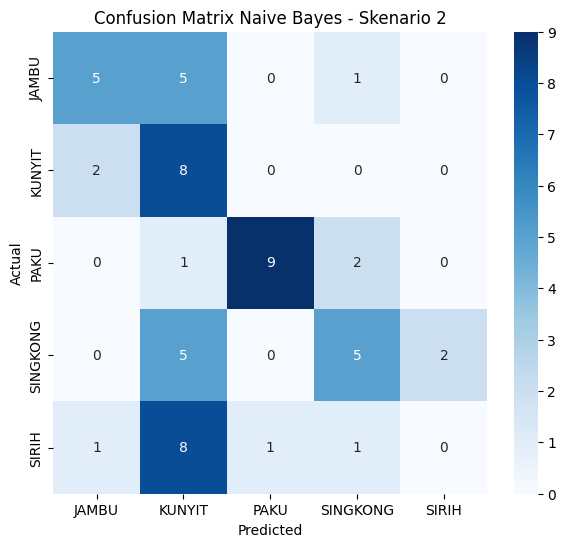


Model skenario 2 berhasil disimpan.


In [36]:
scenario = 2

X_train_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_images, contour_images)
])

X_test_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_test, contour_test)
])

results_s2, scaler_s2 = train_evaluate_save(
    X_train_feat, y_train_aug, X_test_feat, y_test, scenario, encoder
)

all_results[scenario] = results_s2
all_scalers[scenario] = scaler_s2


# SKENARIO 3


############################################################
SKENARIO 3 — shape fitur train: (892, 40), test: (56, 40)
############################################################

SVM
Train Accuracy : 83.97%
Test Accuracy  : 48.21%
              precision    recall  f1-score   support

       JAMBU       0.36      0.45      0.40        11
      KUNYIT       0.62      0.50      0.56        10
        PAKU       0.56      0.75      0.64        12
    SINGKONG       0.38      0.25      0.30        12
       SIRIH       0.50      0.45      0.48        11

    accuracy                           0.48        56
   macro avg       0.48      0.48      0.47        56
weighted avg       0.48      0.48      0.47        56



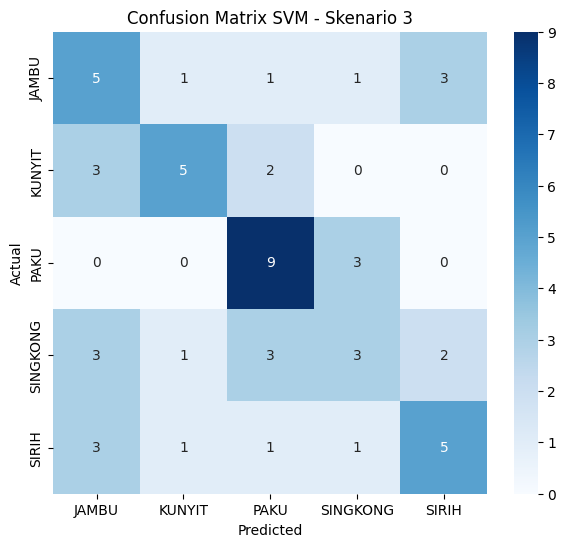


KNN
Train Accuracy : 80.04%
Test Accuracy  : 44.64%
              precision    recall  f1-score   support

       JAMBU       0.20      0.27      0.23        11
      KUNYIT       0.58      0.70      0.64        10
        PAKU       0.69      0.75      0.72        12
    SINGKONG       0.50      0.25      0.33        12
       SIRIH       0.30      0.27      0.29        11

    accuracy                           0.45        56
   macro avg       0.46      0.45      0.44        56
weighted avg       0.46      0.45      0.44        56



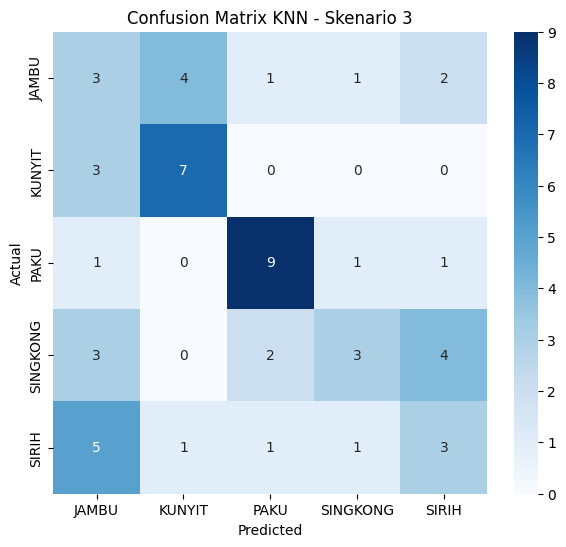


Naive Bayes
Train Accuracy : 63.79%
Test Accuracy  : 60.71%
              precision    recall  f1-score   support

       JAMBU       0.42      0.45      0.43        11
      KUNYIT       0.89      0.80      0.84        10
        PAKU       0.71      0.83      0.77        12
    SINGKONG       0.67      0.33      0.44        12
       SIRIH       0.47      0.64      0.54        11

    accuracy                           0.61        56
   macro avg       0.63      0.61      0.61        56
weighted avg       0.63      0.61      0.60        56



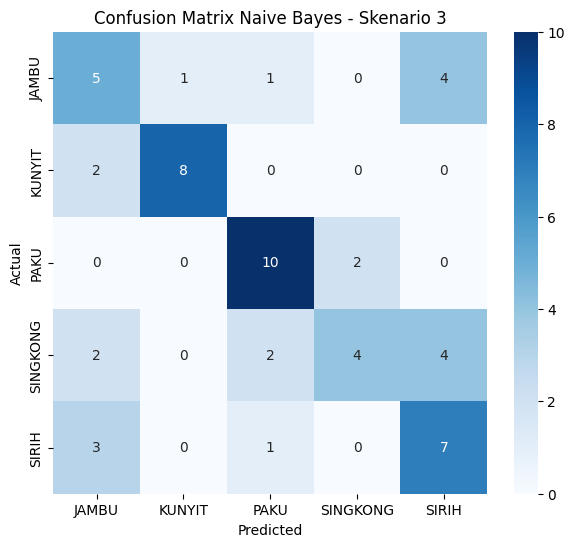


Model skenario 3 berhasil disimpan.


In [37]:
scenario = 3

X_train_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_images, contour_images)
])

X_test_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_test, contour_test)
])

results_s3, scaler_s3 = train_evaluate_save(
    X_train_feat, y_train_aug, X_test_feat, y_test, scenario, encoder
)

all_results[scenario] = results_s3
all_scalers[scenario] = scaler_s3


# SKENARIO 4


############################################################
SKENARIO 4 — shape fitur train: (892, 49), test: (56, 49)
############################################################

SVM
Train Accuracy : 93.95%
Test Accuracy  : 64.29%
              precision    recall  f1-score   support

       JAMBU       0.54      0.64      0.58        11
      KUNYIT       0.73      0.80      0.76        10
        PAKU       0.64      0.58      0.61        12
    SINGKONG       0.55      0.50      0.52        12
       SIRIH       0.80      0.73      0.76        11

    accuracy                           0.64        56
   macro avg       0.65      0.65      0.65        56
weighted avg       0.65      0.64      0.64        56



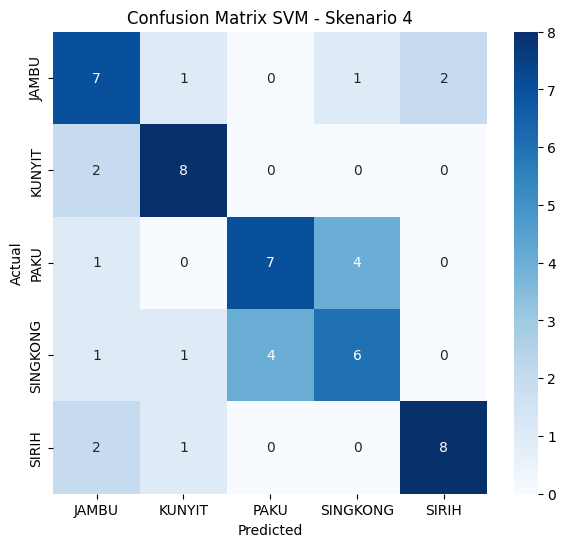


KNN
Train Accuracy : 88.34%
Test Accuracy  : 73.21%
              precision    recall  f1-score   support

       JAMBU       0.53      0.91      0.67        11
      KUNYIT       0.80      0.80      0.80        10
        PAKU       0.79      0.92      0.85        12
    SINGKONG       1.00      0.58      0.74        12
       SIRIH       0.83      0.45      0.59        11

    accuracy                           0.73        56
   macro avg       0.79      0.73      0.73        56
weighted avg       0.79      0.73      0.73        56



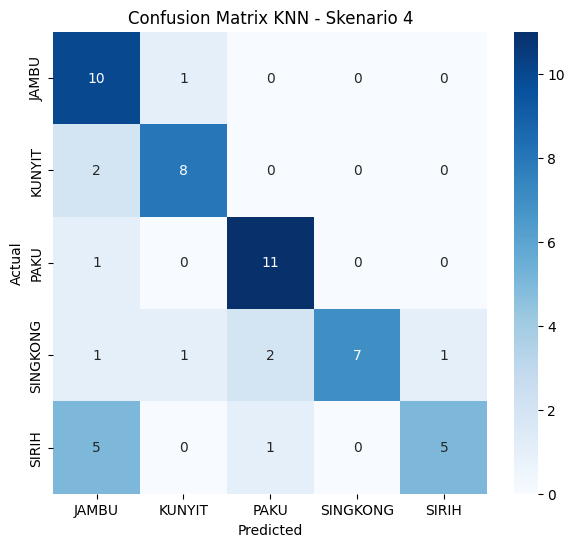


Naive Bayes
Train Accuracy : 67.38%
Test Accuracy  : 67.86%
              precision    recall  f1-score   support

       JAMBU       0.62      0.73      0.67        11
      KUNYIT       0.89      0.80      0.84        10
        PAKU       0.91      0.83      0.87        12
    SINGKONG       0.67      0.50      0.57        12
       SIRIH       0.43      0.55      0.48        11

    accuracy                           0.68        56
   macro avg       0.70      0.68      0.69        56
weighted avg       0.70      0.68      0.68        56



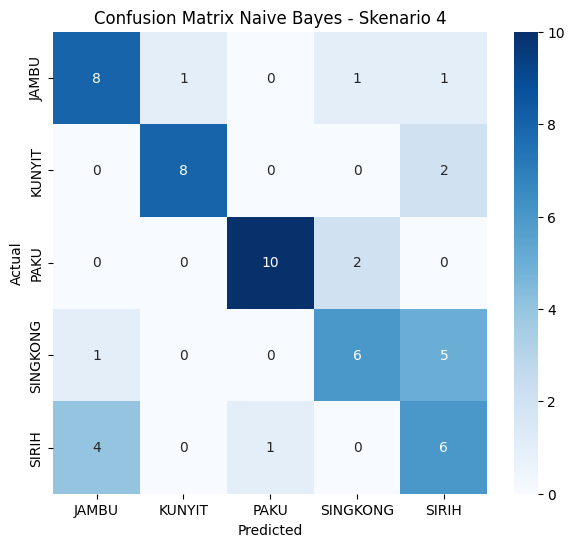


Model skenario 4 berhasil disimpan.


In [38]:
scenario = 4

X_train_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_images, contour_images)
])

X_test_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_test, contour_test)
])

results_s4, scaler_s4 = train_evaluate_save(
    X_train_feat, y_train_aug, X_test_feat, y_test, scenario, encoder
)

all_results[scenario] = results_s4
all_scalers[scenario] = scaler_s4


# SKENARIO 5


############################################################
SKENARIO 5 — shape fitur train: (892, 44), test: (56, 44)
############################################################

SVM
Train Accuracy : 87.22%
Test Accuracy  : 48.21%
              precision    recall  f1-score   support

       JAMBU       0.23      0.27      0.25        11
      KUNYIT       0.58      0.70      0.64        10
        PAKU       0.64      0.75      0.69        12
    SINGKONG       0.57      0.33      0.42        12
       SIRIH       0.40      0.36      0.38        11

    accuracy                           0.48        56
   macro avg       0.49      0.48      0.48        56
weighted avg       0.49      0.48      0.48        56



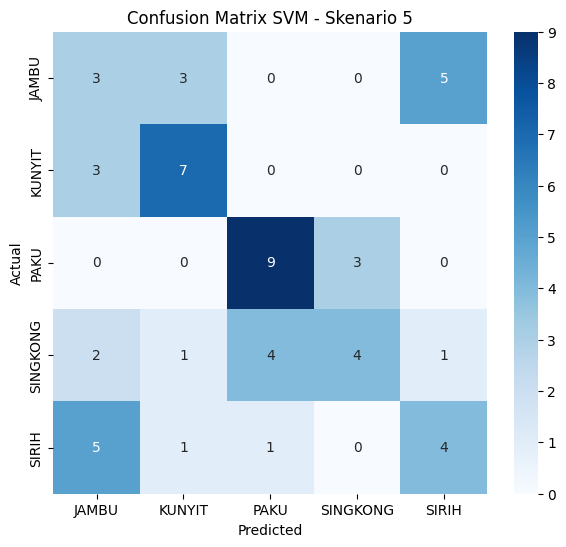


KNN
Train Accuracy : 87.33%
Test Accuracy  : 51.79%
              precision    recall  f1-score   support

       JAMBU       0.35      0.55      0.43        11
      KUNYIT       0.60      0.60      0.60        10
        PAKU       0.73      0.67      0.70        12
    SINGKONG       0.83      0.42      0.56        12
       SIRIH       0.33      0.36      0.35        11

    accuracy                           0.52        56
   macro avg       0.57      0.52      0.53        56
weighted avg       0.58      0.52      0.53        56



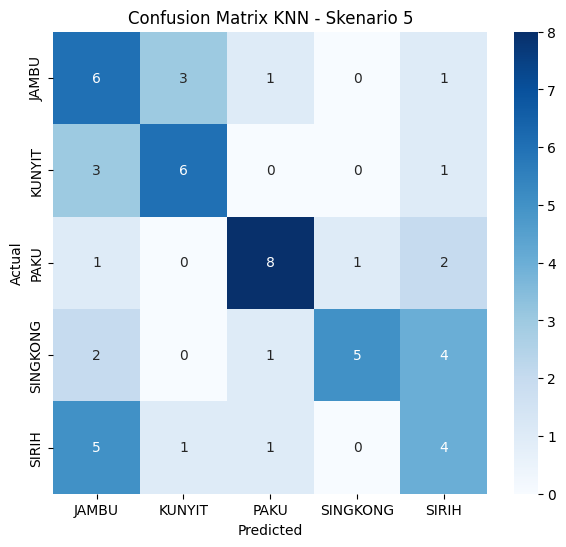


Naive Bayes
Train Accuracy : 64.46%
Test Accuracy  : 64.29%
              precision    recall  f1-score   support

       JAMBU       0.46      0.55      0.50        11
      KUNYIT       0.89      0.80      0.84        10
        PAKU       0.82      0.75      0.78        12
    SINGKONG       0.67      0.50      0.57        12
       SIRIH       0.50      0.64      0.56        11

    accuracy                           0.64        56
   macro avg       0.67      0.65      0.65        56
weighted avg       0.67      0.64      0.65        56



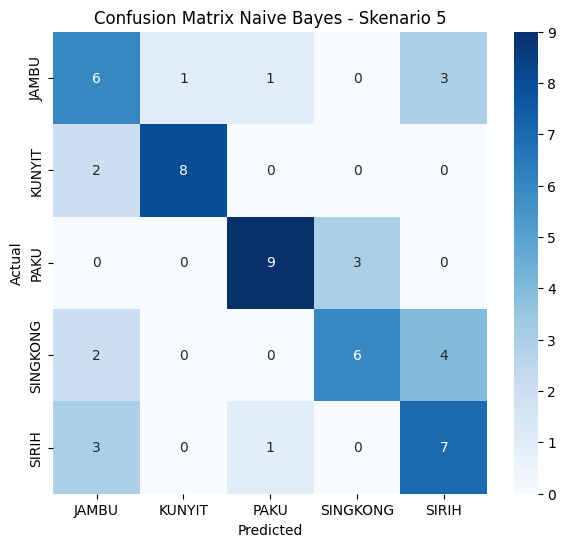


Model skenario 5 berhasil disimpan.


In [39]:
scenario = 5

X_train_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_images, contour_images)
])

X_test_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_test, contour_test)
])

results_s5, scaler_s5 = train_evaluate_save(
    X_train_feat, y_train_aug, X_test_feat, y_test, scenario, encoder
)

all_results[scenario] = results_s5
all_scalers[scenario] = scaler_s5


# SKENARIO 6


############################################################
SKENARIO 6 — shape fitur train: (892, 53), test: (56, 53)
############################################################

SVM
Train Accuracy : 94.62%
Test Accuracy  : 73.21%
              precision    recall  f1-score   support

       JAMBU       0.62      0.73      0.67        11
      KUNYIT       0.80      0.80      0.80        10
        PAKU       0.75      0.75      0.75        12
    SINGKONG       0.64      0.58      0.61        12
       SIRIH       0.90      0.82      0.86        11

    accuracy                           0.73        56
   macro avg       0.74      0.74      0.74        56
weighted avg       0.74      0.73      0.73        56



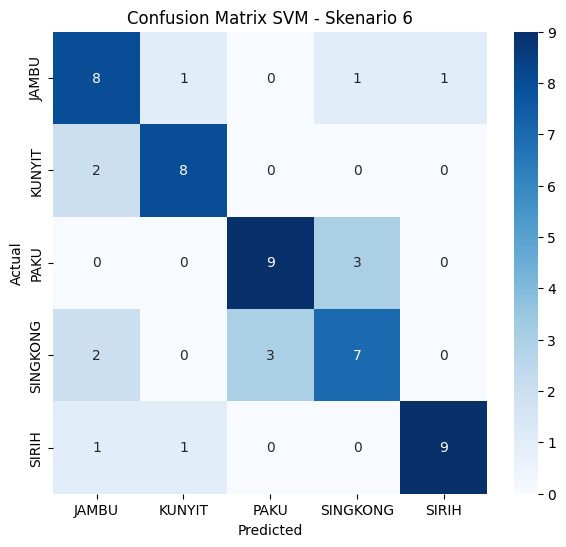


KNN
Train Accuracy : 90.58%
Test Accuracy  : 75.00%
              precision    recall  f1-score   support

       JAMBU       0.60      0.82      0.69        11
      KUNYIT       0.82      0.90      0.86        10
        PAKU       0.91      0.83      0.87        12
    SINGKONG       0.80      0.67      0.73        12
       SIRIH       0.67      0.55      0.60        11

    accuracy                           0.75        56
   macro avg       0.76      0.75      0.75        56
weighted avg       0.76      0.75      0.75        56



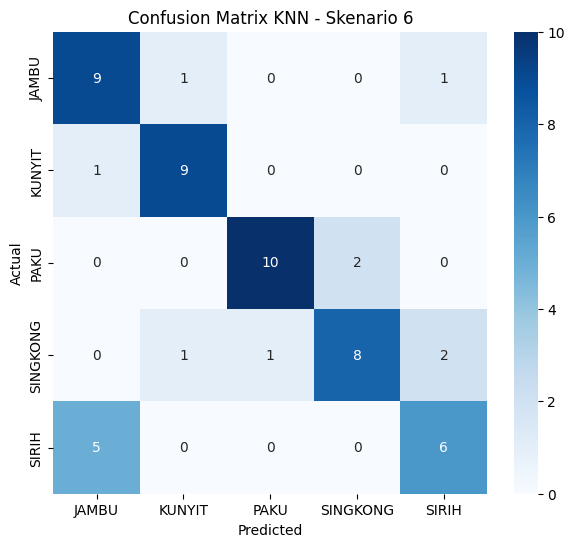


Naive Bayes
Train Accuracy : 66.93%
Test Accuracy  : 69.64%
              precision    recall  f1-score   support

       JAMBU       0.67      0.73      0.70        11
      KUNYIT       0.89      0.80      0.84        10
        PAKU       0.83      0.83      0.83        12
    SINGKONG       0.67      0.50      0.57        12
       SIRIH       0.50      0.64      0.56        11

    accuracy                           0.70        56
   macro avg       0.71      0.70      0.70        56
weighted avg       0.71      0.70      0.70        56



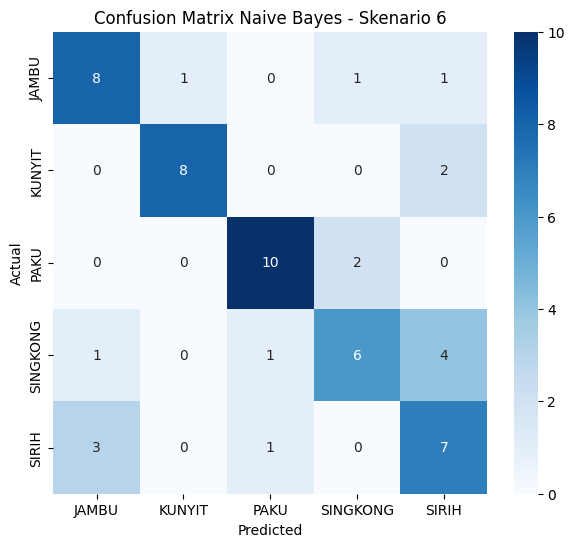


Model skenario 6 berhasil disimpan.


In [40]:
scenario = 6

X_train_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_images, contour_images)
])

X_test_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_test, contour_test)
])

results_s6, scaler_s6 = train_evaluate_save(
    X_train_feat, y_train_aug, X_test_feat, y_test, scenario, encoder
)

all_results[scenario] = results_s6
all_scalers[scenario] = scaler_s6


# SKENARIO 7


############################################################
SKENARIO 7 — shape fitur train: (892, 9), test: (56, 9)
############################################################

SVM
Train Accuracy : 86.77%
Test Accuracy  : 78.57%
              precision    recall  f1-score   support

       JAMBU       0.79      1.00      0.88        11
      KUNYIT       1.00      0.90      0.95        10
        PAKU       0.75      0.50      0.60        12
    SINGKONG       0.57      0.67      0.62        12
       SIRIH       0.91      0.91      0.91        11

    accuracy                           0.79        56
   macro avg       0.80      0.80      0.79        56
weighted avg       0.79      0.79      0.78        56



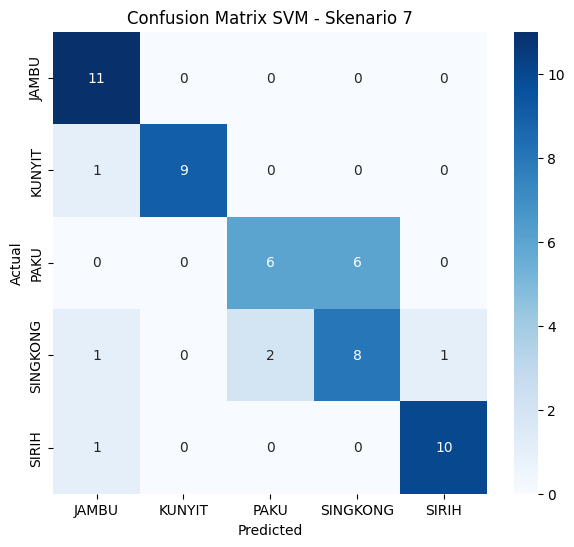


KNN
Train Accuracy : 92.83%
Test Accuracy  : 75.00%
              precision    recall  f1-score   support

       JAMBU       0.64      0.64      0.64        11
      KUNYIT       0.91      1.00      0.95        10
        PAKU       1.00      0.67      0.80        12
    SINGKONG       0.69      0.75      0.72        12
       SIRIH       0.62      0.73      0.67        11

    accuracy                           0.75        56
   macro avg       0.77      0.76      0.76        56
weighted avg       0.77      0.75      0.75        56



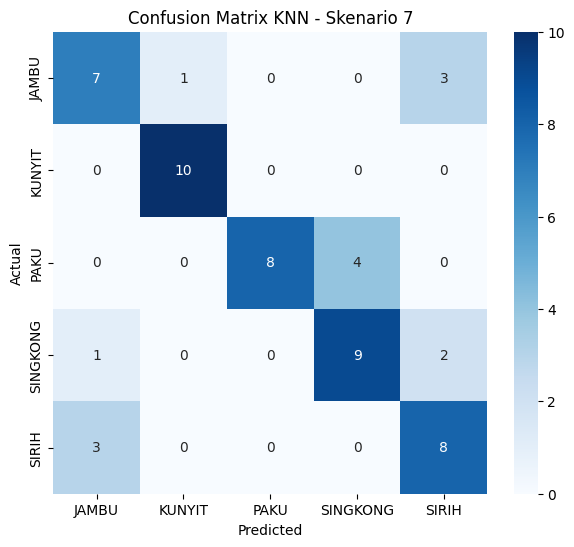


Naive Bayes
Train Accuracy : 75.11%
Test Accuracy  : 67.86%
              precision    recall  f1-score   support

       JAMBU       0.73      0.73      0.73        11
      KUNYIT       1.00      1.00      1.00        10
        PAKU       0.62      0.67      0.64        12
    SINGKONG       0.60      0.50      0.55        12
       SIRIH       0.50      0.55      0.52        11

    accuracy                           0.68        56
   macro avg       0.69      0.69      0.69        56
weighted avg       0.68      0.68      0.68        56



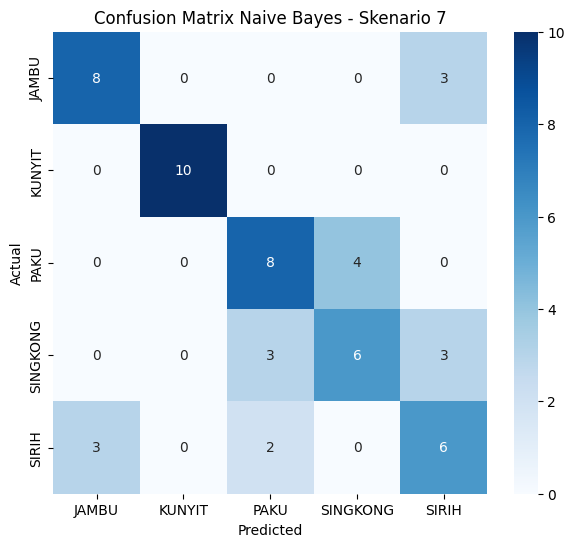


Model skenario 7 berhasil disimpan.


In [41]:
scenario = 7

X_train_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_images, contour_images)
])

X_test_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_test, contour_test)
])

results_s7, scaler_s7 = train_evaluate_save(
    X_train_feat, y_train_aug, X_test_feat, y_test, scenario, encoder
)

all_results[scenario] = results_s7
all_scalers[scenario] = scaler_s7


# SKENARIO 8


############################################################
SKENARIO 8 — shape fitur train: (892, 18), test: (56, 18)
############################################################

SVM
Train Accuracy : 91.48%
Test Accuracy  : 91.07%
              precision    recall  f1-score   support

       JAMBU       0.92      1.00      0.96        11
      KUNYIT       1.00      0.90      0.95        10
        PAKU       1.00      0.67      0.80        12
    SINGKONG       0.75      1.00      0.86        12
       SIRIH       1.00      1.00      1.00        11

    accuracy                           0.91        56
   macro avg       0.93      0.91      0.91        56
weighted avg       0.93      0.91      0.91        56



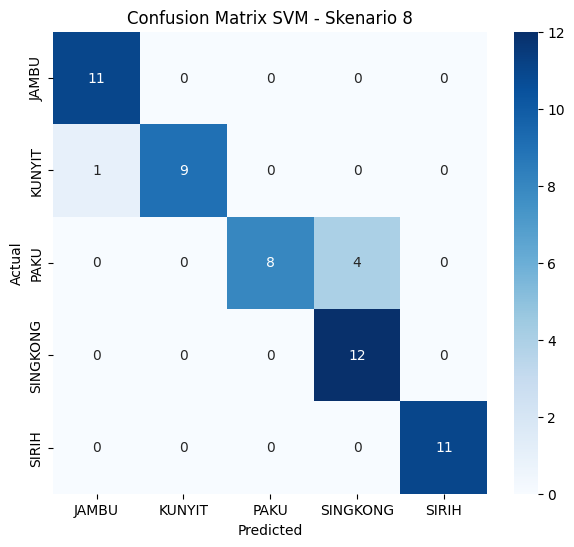


KNN
Train Accuracy : 93.61%
Test Accuracy  : 78.57%
              precision    recall  f1-score   support

       JAMBU       0.64      0.82      0.72        11
      KUNYIT       1.00      0.90      0.95        10
        PAKU       0.92      0.92      0.92        12
    SINGKONG       0.88      0.58      0.70        12
       SIRIH       0.62      0.73      0.67        11

    accuracy                           0.79        56
   macro avg       0.81      0.79      0.79        56
weighted avg       0.81      0.79      0.79        56



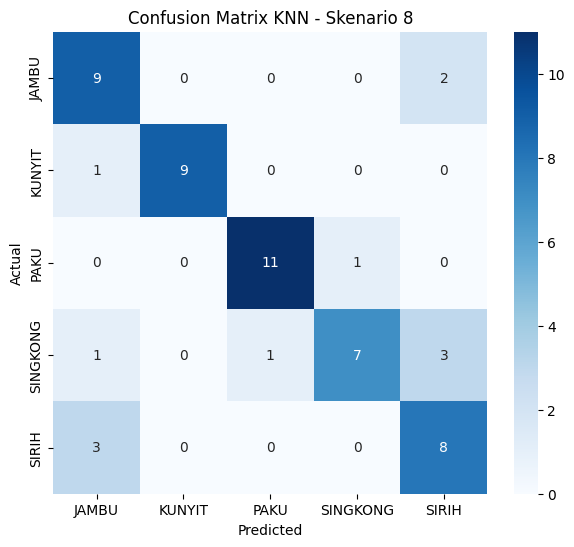


Naive Bayes
Train Accuracy : 75.56%
Test Accuracy  : 71.43%
              precision    recall  f1-score   support

       JAMBU       0.71      0.91      0.80        11
      KUNYIT       0.90      0.90      0.90        10
        PAKU       0.77      0.83      0.80        12
    SINGKONG       0.56      0.42      0.48        12
       SIRIH       0.60      0.55      0.57        11

    accuracy                           0.71        56
   macro avg       0.71      0.72      0.71        56
weighted avg       0.70      0.71      0.70        56



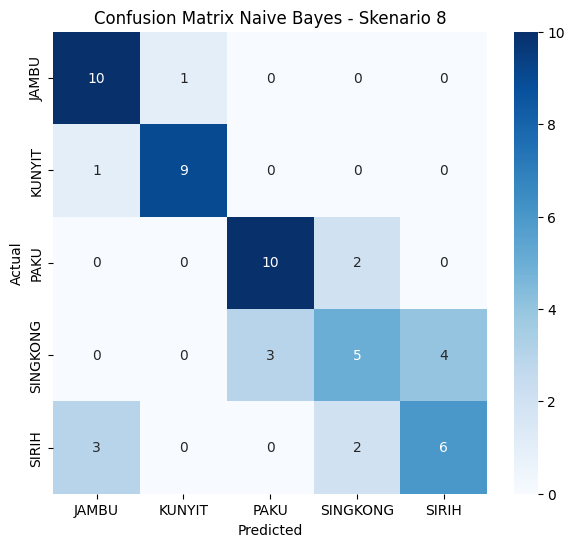


Model skenario 8 berhasil disimpan.


In [42]:
scenario = 8

X_train_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_images, contour_images)
])

X_test_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_test, contour_test)
])

results_s8, scaler_s8 = train_evaluate_save(
    X_train_feat, y_train_aug, X_test_feat, y_test, scenario, encoder
)

all_results[scenario] = results_s8
all_scalers[scenario] = scaler_s8


# SKENARIO 9


############################################################
SKENARIO 9 — shape fitur train: (892, 13), test: (56, 13)
############################################################

SVM
Train Accuracy : 89.57%
Test Accuracy  : 83.93%
              precision    recall  f1-score   support

       JAMBU       0.85      1.00      0.92        11
      KUNYIT       1.00      0.90      0.95        10
        PAKU       0.78      0.58      0.67        12
    SINGKONG       0.67      0.83      0.74        12
       SIRIH       1.00      0.91      0.95        11

    accuracy                           0.84        56
   macro avg       0.86      0.85      0.84        56
weighted avg       0.85      0.84      0.84        56



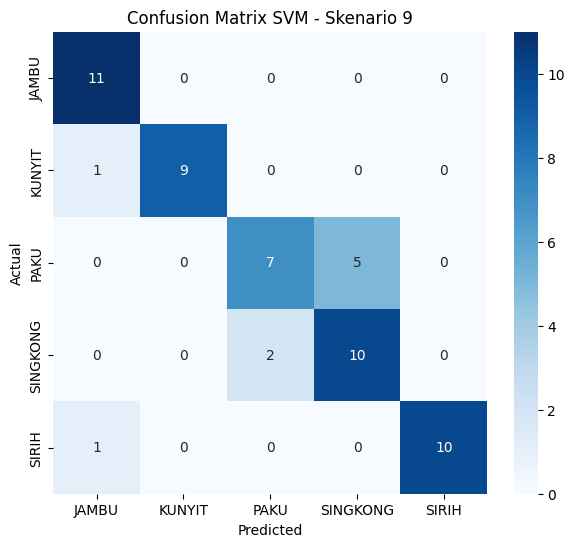


KNN
Train Accuracy : 93.05%
Test Accuracy  : 83.93%
              precision    recall  f1-score   support

       JAMBU       0.83      0.91      0.87        11
      KUNYIT       0.83      1.00      0.91        10
        PAKU       1.00      0.83      0.91        12
    SINGKONG       0.80      0.67      0.73        12
       SIRIH       0.75      0.82      0.78        11

    accuracy                           0.84        56
   macro avg       0.84      0.85      0.84        56
weighted avg       0.85      0.84      0.84        56



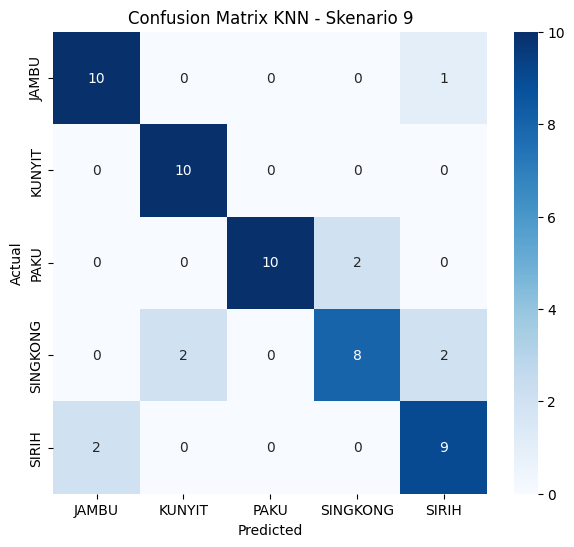


Naive Bayes
Train Accuracy : 73.43%
Test Accuracy  : 67.86%
              precision    recall  f1-score   support

       JAMBU       0.64      0.82      0.72        11
      KUNYIT       0.82      0.90      0.86        10
        PAKU       0.75      0.75      0.75        12
    SINGKONG       0.60      0.50      0.55        12
       SIRIH       0.56      0.45      0.50        11

    accuracy                           0.68        56
   macro avg       0.67      0.68      0.67        56
weighted avg       0.67      0.68      0.67        56



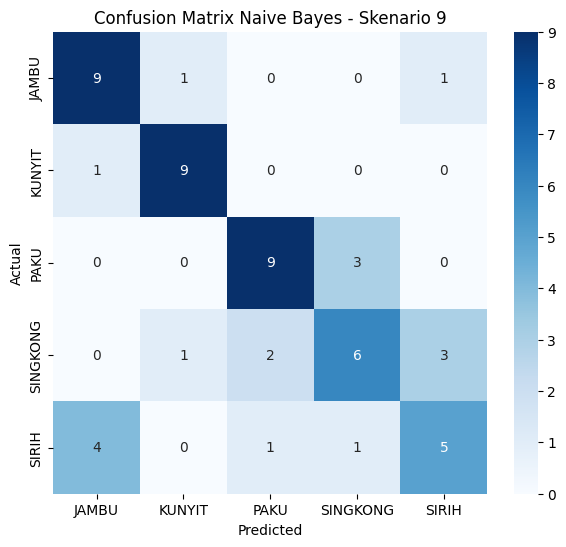


Model skenario 9 berhasil disimpan.


In [43]:
scenario = 9

X_train_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_images, contour_images)
])

X_test_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_test, contour_test)
])

results_s9, scaler_s9 = train_evaluate_save(
    X_train_feat, y_train_aug, X_test_feat, y_test, scenario, encoder
)

all_results[scenario] = results_s9
all_scalers[scenario] = scaler_s9


# SKENARIO 10


############################################################
SKENARIO 10 — shape fitur train: (892, 22), test: (56, 22)
############################################################

SVM
Train Accuracy : 91.82%
Test Accuracy  : 91.07%
              precision    recall  f1-score   support

       JAMBU       0.92      1.00      0.96        11
      KUNYIT       1.00      0.90      0.95        10
        PAKU       1.00      0.67      0.80        12
    SINGKONG       0.75      1.00      0.86        12
       SIRIH       1.00      1.00      1.00        11

    accuracy                           0.91        56
   macro avg       0.93      0.91      0.91        56
weighted avg       0.93      0.91      0.91        56



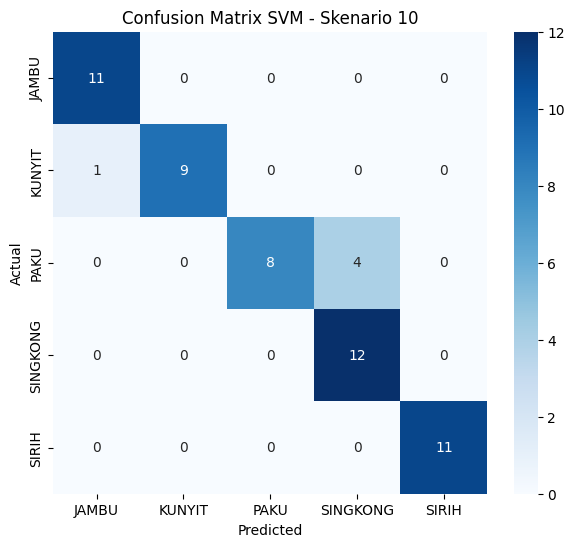


KNN
Train Accuracy : 93.61%
Test Accuracy  : 76.79%
              precision    recall  f1-score   support

       JAMBU       0.56      0.82      0.67        11
      KUNYIT       1.00      0.90      0.95        10
        PAKU       1.00      0.83      0.91        12
    SINGKONG       0.80      0.67      0.73        12
       SIRIH       0.64      0.64      0.64        11

    accuracy                           0.77        56
   macro avg       0.80      0.77      0.78        56
weighted avg       0.80      0.77      0.78        56



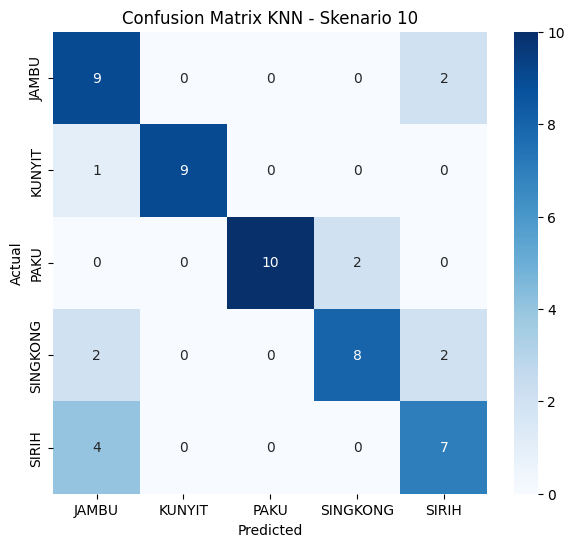


Naive Bayes
Train Accuracy : 73.88%
Test Accuracy  : 71.43%
              precision    recall  f1-score   support

       JAMBU       0.71      0.91      0.80        11
      KUNYIT       0.90      0.90      0.90        10
        PAKU       0.75      0.75      0.75        12
    SINGKONG       0.56      0.42      0.48        12
       SIRIH       0.64      0.64      0.64        11

    accuracy                           0.71        56
   macro avg       0.71      0.72      0.71        56
weighted avg       0.71      0.71      0.71        56



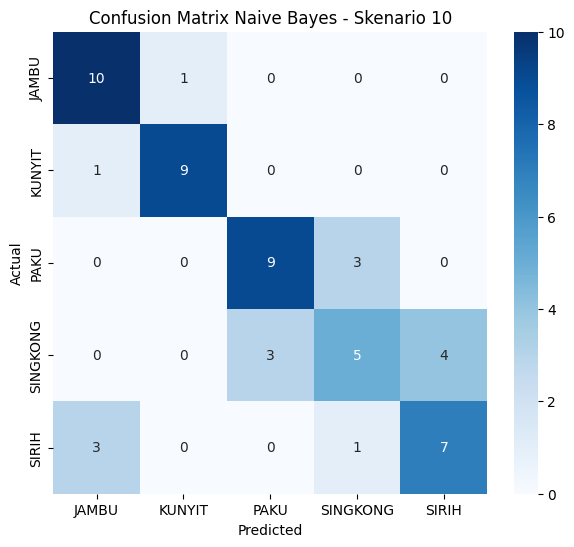


Model skenario 10 berhasil disimpan.


In [44]:
scenario = 10

X_train_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_images, contour_images)
])

X_test_feat = np.array([
    extract_features_scenario(g, c, scenario)
    for g, c in zip(gray_test, contour_test)
])

results_s10, scaler_s10 = train_evaluate_save(
    X_train_feat, y_train_aug, X_test_feat, y_test, scenario, encoder
)

all_results[scenario] = results_s10
all_scalers[scenario] = scaler_s10


## Ringkasan Hasil Semua Skenario


          Skenario       Model  Train Accuracy (%)  Test Accuracy (%)
            2: LBP         SVM               61.77              60.71
            2: LBP         KNN               84.08              57.14
            2: LBP Naive Bayes               45.85              48.21
             3: FD         SVM               83.97              48.21
             3: FD         KNN               80.04              44.64
             3: FD Naive Bayes               63.79              60.71
        4: GLCM+FD         SVM               93.95              64.29
        4: GLCM+FD         KNN               88.34              73.21
        4: GLCM+FD Naive Bayes               67.38              67.86
         5: LBP+FD         SVM               87.22              48.21
         5: LBP+FD         KNN               87.33              51.79
         5: LBP+FD Naive Bayes               64.46              64.29
    6: GLCM+LBP+FD         SVM               94.62              73.21
    6: GLCM+LBP+FD  

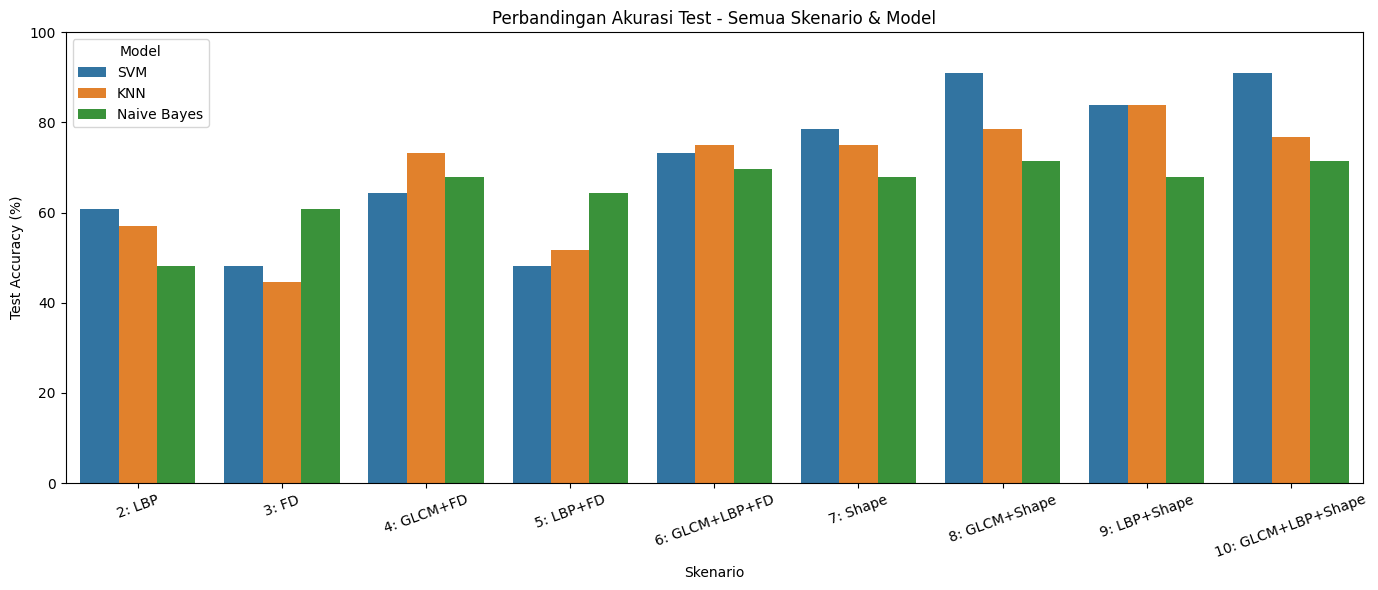

In [45]:
summary_rows = []

for scenario_num, results in all_results.items():
    for model_name, metrics in results.items():
        summary_rows.append({
            "Skenario": SCENARIO_LABELS[scenario_num],
            "Model": model_name,
            "Train Accuracy (%)": round(metrics["train_acc"] * 100, 2),
            "Test Accuracy (%)": round(metrics["test_acc"] * 100, 2)
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

plt.figure(figsize=(14, 6))
sns.barplot(data=summary_df, x="Skenario", y="Test Accuracy (%)", hue="Model")
plt.title("Perbandingan Akurasi Test - Semua Skenario & Model")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [66]:
def load_image_rgb(image_path):

    img = cv2.imread(image_path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [67]:
def load_all_models():
    models = {}
    scalers = {}
    for scenario in range(1, 11):
        models[scenario] = {
            "SVM": joblib.load(f"svm_s{scenario}.pkl"),
            "KNN": joblib.load(f"knn_s{scenario}.pkl"),
            "Naive Bayes": joblib.load(f"nb_s{scenario}.pkl"),
        }
        scalers[scenario] = joblib.load(f"scaler_s{scenario}.pkl")
    enc = joblib.load("label_encoder.pkl")
    return models, scalers, enc

In [68]:
def predict_best_model(image_path, target_scenario, target_model, models, scalers, encoder):
    
    model = models[target_scenario][target_model]
    scaler = scalers[target_scenario]
    
    img_rgb = load_image_rgb(image_path)
    img_rgb = cv2.resize(img_rgb, IMG_SIZE)
    img_no_bg = remove_bg(img_rgb)
    gray = grayscale(img_no_bg)
    thresh = otsu_threshold(gray)
    contour = contour_detection(thresh)

    contour_overlay = img_rgb.copy()
    if contour is not None:
        cv2.drawContours(contour_overlay, [contour], -1, (255, 0, 0), 2)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img_rgb); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(img_no_bg); axes[1].set_title("Remove BG"); axes[1].axis("off")
    axes[2].imshow(thresh, cmap="gray"); axes[2].set_title("Threshold"); axes[2].axis("off")
    axes[3].imshow(contour_overlay); axes[3].set_title("Contour"); axes[3].axis("off")
    plt.tight_layout()
    plt.show()

    feature = extract_features_scenario(gray, contour, target_scenario)
    feature = scaler.transform(feature.reshape(1, -1))

    pred_idx = model.predict(feature)[0]
    label = encoder.inverse_transform([pred_idx])[0]
    
    proba = model.predict_proba(feature)[0]
    class_labels = encoder.inverse_transform(model.classes_)
    proba_dict = {lab: round(p * 100, 2) for lab, p in zip(class_labels, proba)}
    
    return label, proba_dict

In [72]:
models, scalers, encoder = load_all_models()

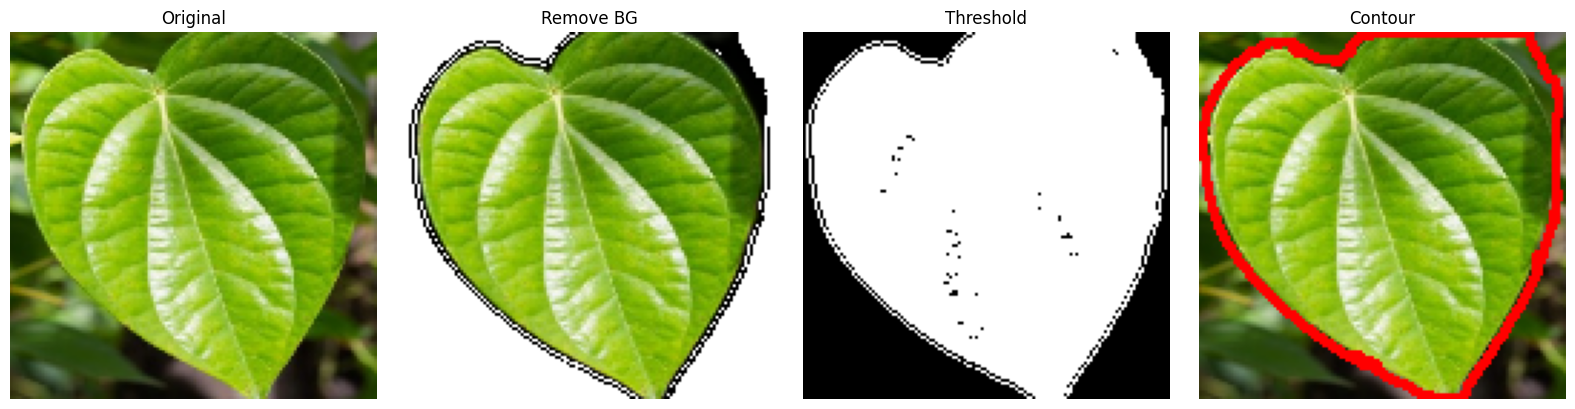

Hasil Prediksi Utama: SIRIH

Skor Kepercayaan (Probabilitas):
- JAMBU: 0.29%
- KUNYIT: 0.13%
- PAKU: 1.68%
- SINGKONG: 0.14%
- SIRIH: 97.76%


In [77]:
TEST_IMAGE = "CITRA BARU/sirih.png"
BEST_SCENARIO = 8  
BEST_MODEL = "SVM" 

label, probabilitas = predict_best_model(TEST_IMAGE, BEST_SCENARIO, BEST_MODEL, models, scalers, encoder)

print(f"Hasil Prediksi Utama: {label}")
print("\nSkor Kepercayaan (Probabilitas):")
for kelas, nilai in probabilitas.items():
    print(f"- {kelas}: {nilai}%")

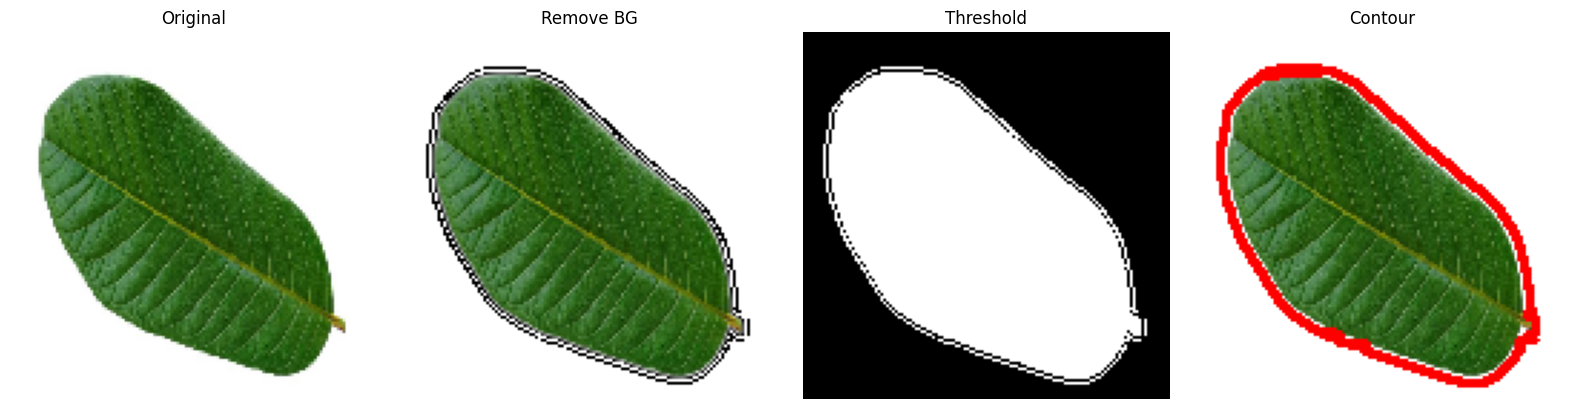

Hasil Prediksi Utama: JAMBU

Skor Kepercayaan (Probabilitas):
- JAMBU: 72.98%
- KUNYIT: 0.22%
- PAKU: 0.89%
- SINGKONG: 1.17%
- SIRIH: 24.75%


In [79]:
TEST_IMAGE = "CITRA BARU/jambu1.png"
BEST_SCENARIO = 8  
BEST_MODEL = "SVM" 

label, probabilitas = predict_best_model(TEST_IMAGE, BEST_SCENARIO, BEST_MODEL, models, scalers, encoder)

print(f"Hasil Prediksi Utama: {label}")
print("\nSkor Kepercayaan (Probabilitas):")
for kelas, nilai in probabilitas.items():
    print(f"- {kelas}: {nilai}%")

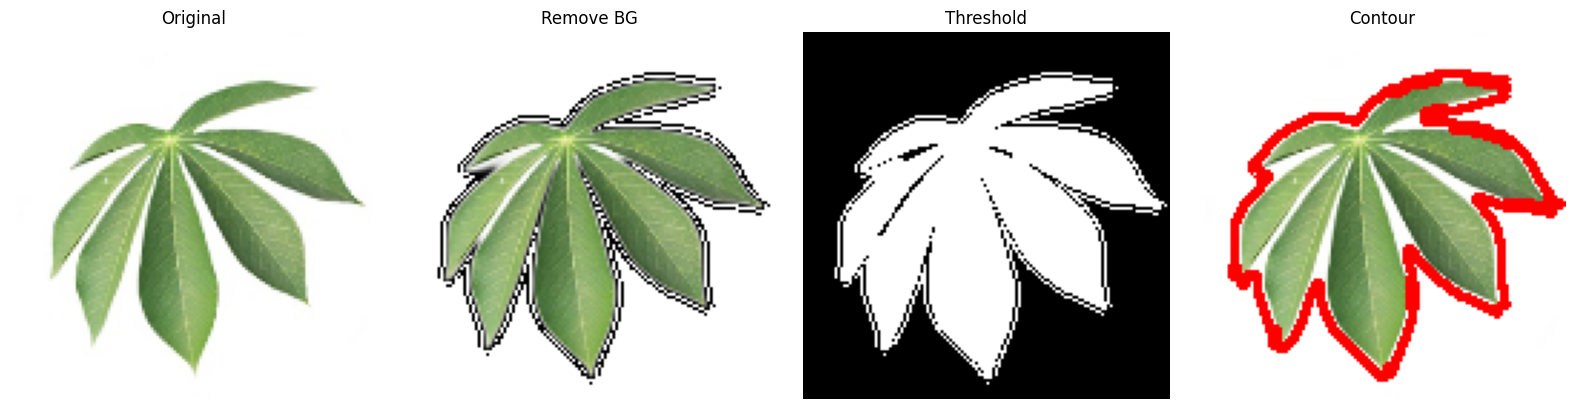

Hasil Prediksi Utama: SINGKONG

Skor Kepercayaan (Probabilitas):
- JAMBU: 0.28%
- KUNYIT: 0.04%
- PAKU: 21.96%
- SINGKONG: 75.24%
- SIRIH: 2.49%


In [83]:
TEST_IMAGE = "CITRA BARU/singkong1.png"
BEST_SCENARIO = 8  
BEST_MODEL = "SVM" 

label, probabilitas = predict_best_model(TEST_IMAGE, BEST_SCENARIO, BEST_MODEL, models, scalers, encoder)

print(f"Hasil Prediksi Utama: {label}")
print("\nSkor Kepercayaan (Probabilitas):")
for kelas, nilai in probabilitas.items():
    print(f"- {kelas}: {nilai}%")

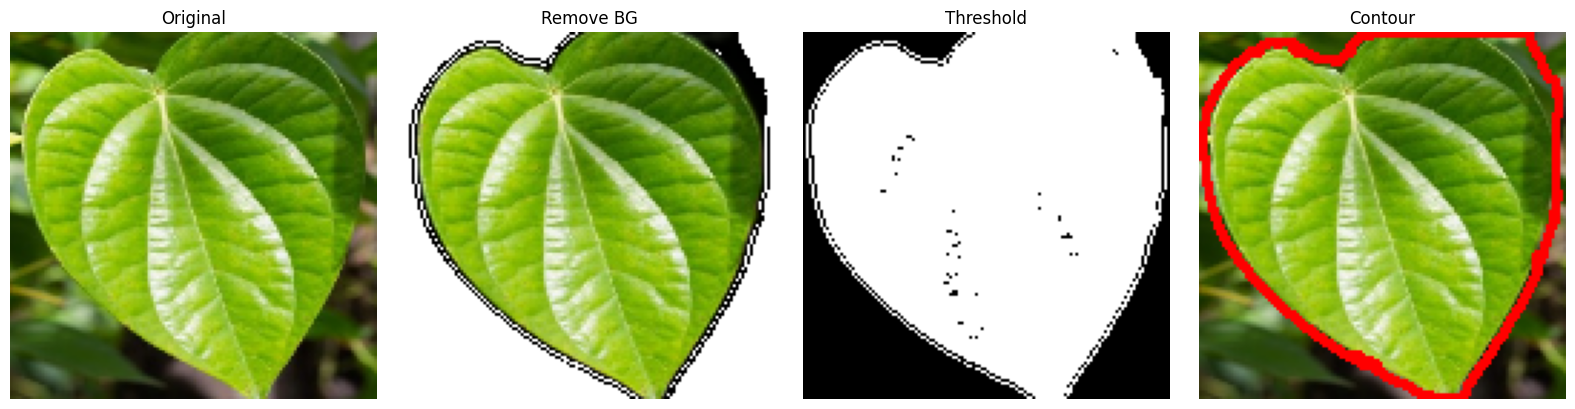

Hasil Prediksi Utama: SIRIH

Skor Kepercayaan (Probabilitas):
- JAMBU: 0.29%
- KUNYIT: 0.13%
- PAKU: 1.68%
- SINGKONG: 0.14%
- SIRIH: 97.76%


In [84]:
TEST_IMAGE = "CITRA BARU/sirih.png"
BEST_SCENARIO = 8  
BEST_MODEL = "SVM" 

label, probabilitas = predict_best_model(TEST_IMAGE, BEST_SCENARIO, BEST_MODEL, models, scalers, encoder)

print(f"Hasil Prediksi Utama: {label}")
print("\nSkor Kepercayaan (Probabilitas):")
for kelas, nilai in probabilitas.items():
    print(f"- {kelas}: {nilai}%")